## Homework 4: due 2024/05/14 23:59 (100%)

### - Tutorial : 

1. Transfer Learning for Computer Vision Tutorial: https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html#convnet-as-fixed-feature-extractor
2. Torchvision transforms: https://pytorch.org/vision/stable/transforms.html
3. Torchvision models: https://pytorch.org/vision/stable/models.html
4. Pytorch learning rate scheduler: https://pytorch.org/docs/stable/optim.html
5. How to get learning rate: https://stackoverflow.com/questions/52660985/pytorch-how-to-get-learning-rate-during-training
6. Pytorch tutorials: https://pytorch.org/tutorials/index.html#

### - After you go through the tutorials, you should be able to work on this assignment.

### - Please answer the following questions and work directly on this jupyter notebook.

### - Make sure the code can be run and show the result and figures properly.

### - Please write down your observation with markdown in this notebook briefly.



#### You will train a multi-class classification model in this part. The data contains the images with three categories: cats, dogs and pandas. You can find the details of each column at https://www.kaggle.com/datasets/ashishsaxena2209/animal-image-datasetdog-cat-and-panda.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os            # for os.path.join.....  Provides functions to interact with the operating system.Useful for working with files, directories, paths, environment variables.
import random
import time
import glob          # for glob.glob # for finding files and directories matching a specified pattern. useful when working with lots of files. 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from tqdm import tqdm

cudnn.benchmark = True   #Try several different convolution implementations available in cuDNN (NVIDIA’s deep learning library). and picks the fastest one for your hardware and input size."
plt.ion()   # interactive mode in matplotlib 1. You can see plots live as they’re updated 2. Plots don’t block the rest of your code 3. Useful in loops, real-time data, training visualizations

In [2]:
torch.manual_seed(0)
random.seed(0)
np.random.seed(0)

| Line                   | Seeds randomness from | Use it when                       |
| ---------------------- | --------------------- | --------------------------------- |
| `torch.manual_seed(0)` | PyTorch               | For consistent training results   |
| `random.seed(0)`       | Python's `random`     | For random shuffles, sampling     |
| `np.random.seed(0)`    | NumPy                 | For NumPy-generated data or noise |


In [3]:
# Define the device 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


### 1. Define the model and dataset (20%)

#### 1.1 Please create the train/validation dataloaders with the data from the __animals__ folder. You can use the function from __torchvision.datasets.ImageFolder__ to load the data. In the training dataset, you should resize the images to 224x224, randomly horizontal flip the images, and normalize the images with mean [0.485, 0.456, 0.406] and standard deviation [0.229, 0.224, 0.225]. As for the validation dataset, do the same transfromation with the training dataset but without flipping the images.(15%)


##### (Note. The default batch size is 4; however, if your hardware can not afford the computation, you can decrease the batch size.)

In [4]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),   
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'animals'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}   # output: (image, label)  # prepare and transform data for data loader
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, pin_memory=True) for x in ['train', 'val']}  # create data loaders for training and validation sets

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

(os.path.join(data_dir, x) : It's a cross-platform-safe way to join folder and file names into a path.

### what we use:
online augamentaions : Happens during data loading, not before.

The dataset size does NOT change.

But the model sees a different version of the same image on every epoch. 

## Guide on Transformation  
Fantastic question!
**"How much transformation should I use?"** depends on your **data**, **model**, and **goal**.

Let’s break this into **clear principles** + a decision guide so you know **how far to go** with your data augmentation (transformations).

---

### 🎯 **1. What is your dataset like?**

| Dataset Type                  | Recommendation                                     |
| ----------------------------- | -------------------------------------------------- |
| **Large & diverse**           | Use **light** augmentation (e.g. flip, crop)       |
| **Small & limited**           | Use **strong** augmentation to prevent overfitting |
| **Clean & balanced**          | Light to medium augmentation                       |
| **Noisy, biased, imbalanced** | Stronger augmentation can help generalization      |

---

### 🧠 **2. What kind of images?**

| Image Type                          | Suggested Augmentation                                                   |
| ----------------------------------- | ------------------------------------------------------------------------ |
| Natural images (e.g. animals, food) | Flip, crop, color jitter, slight rotation                                |
| Medical images                      | Be **conservative** (avoid rotations or color changes unless known safe) |
| Satellite images                    | Use rotation, scale, perspective, blur                                   |
| Documents / text                    | Avoid aggressive transforms, just crop, resize, maybe flip               |

---

### 🔧 **3. How to experiment wisely**

#### ✅ Start simple:

```python
transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(...)
])
```

Then, **test your model’s validation accuracy**.

#### If overfitting:

* Add `ColorJitter`
* Add `RandomRotation` or `GaussianBlur`

#### If performance drops:

* Reduce randomness (e.g., use `RandomCrop` with smaller range)
* Remove too aggressive transformations

---

### 🔧 **4. A visual rule of thumb**

| Scenario                         | Apply Light Augmentation | Apply Strong Augmentation |
| -------------------------------- | ------------------------ | ------------------------- |
| Validation loss ≈ Training loss  | ✅                        | ❌                         |
| Validation loss >> Training loss | ❌                        | ✅                         |

---

### Final Guide: How much to use?

| Factor                              | Recommendation                                 |
| ----------------------------------- | ---------------------------------------------- |
| Small dataset (few images)          | Use more, stronger augmentation                |
| Big dataset (ImageNet scale)        | Use less, just basic regularization            |
| Pretrained model                    | Stick to common transforms (Resize, Normalize) |
| Real-time system (e.g., mobile app) | Use faster, fewer transforms (performance!)    |

---


### 1.2 Use the function __imshow__ to show the samples of dataset. (5%)

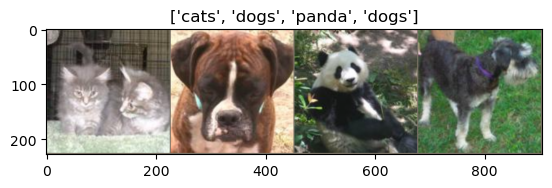

In [5]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean  # unnormalize the image. When displaying an image, you want real pixel values (0–1).
    inp = np.clip(inp, 0, 1)   #After reversing normalization, some pixels might fall outside the valid range.  np.clip(..., 0, 1) ensures all pixel values are between 0 and 1 for display.
    
    plt.imshow(inp)

    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

### **1. inp = np.clip(inp, 0, 1)**
    inp = np.clip(inp, 0, 1)
    
#### 🔹 PyTorch tensors:

* Shape: `[C, H, W]` (channels first)
* Data type: `torch.Tensor`
* Used for model computation, backpropagation, GPU acceleration

#### 🔹 Matplotlib's `imshow()`:

* Shape: `[H, W, C]` (channels last)
* Data type: `np.ndarray` (NumPy array)
* Used for **plotting**, not deep learning


### **2. plt.pause(0.001)**
#### 🛠️ When should I use it?

| Use Case                                    | `plt.pause()` Needed? |
| ------------------------------------------- | --------------------- |
| Static, final plot (just `plt.show()`)      | ❌ Not needed          |
| Inside a loop (e.g., training, time series) | ✅ Yes                 |
| Using `plt.ion()` (interactive mode)        | ✅ Yes                 |
| Animations or updating images live          | ✅ Yes                 |

| Command            | What it does                                               |
| ------------------ | ---------------------------------------------------------- |
| `plt.pause(0.001)` | Tells Matplotlib to **refresh the plot** and pause briefly |
| Why it's needed    | Ensures the plot **updates inside loops or live settings** |
| Use with           | `plt.ion()` or custom training visualizations              |


### **3. inputs, classes = next(iter(dataloaders['train']))**   
In Python, an iterator is an object you can loop over or use with next() to get items one at a time.  
✅ What next(...) does:
- It asks the iterator for the next batch.

- In this case, it gives you the first batch (because the iterator is just created).

- The batch consists of:

- inputs: a tensor of images → shape [batch_size, 3, H, W]

- classes: a tensor of labels → shape [batch_size] (integers)

✅ After this line, you’ve got one mini-batch of training data, and you can now do things like visualize it, send it to a model, or inspect the values.

### **4. out = torchvision.utils.make_grid(inputs)**
| Code                | Purpose                                         |
| ------------------- | ----------------------------------------------- |
| `make_grid(inputs)` | Combines a batch of images into a single tensor |
| Output              | 3D tensor `[C, H_big, W_big]`                   |
| Used with           | `imshow(...)`, `plt.imshow(...)`, TensorBoard   |


### 2. Train the model (80%)

#### 2.1 Define a function called __train_model__ to train the model and record the loss/accuracy/learning rate/time by adapting the codes from the tutorial. Also, save the model with the best accuracy score on the validation dataset. (15%)


In [6]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25, model_name='model'):
    # Step 1: Initialize tracking
    since = time.time()  # Record the start time of training
    train_loss, train_acc, val_loss, val_acc = np.inf, np.inf, np.inf, np.inf
    train_loss_record, train_acc_record, val_loss_record, val_acc_record = list(), list(), list(), list()
    learning_rate_record = list()
    time_record = list()

    # Create a temporary directory to save training checkpoints
    #with TemporaryDirectory() as tempdir:

    # Step 2: Prepare model save path
    model_params_name = model_name + '_best_params.pt'
    best_model_params_path = os.path.join('./model_save/', model_params_name)
    torch.save(model.state_dict(), best_model_params_path)   # Save initial weights


    # Step 3: Training loop
    # Initialize the best accuracy
    best_acc = 0.0
    loop = tqdm(range(num_epochs))  # tqdm is used to create a progress bar for the training loop

    # Loop over epochs
    for epoch in loop:
        loop.set_description(f"Epoch {epoch+1}/{num_epochs}")

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0 # Initialize running loss and correct predictions

            # Step 3.1: Batch loop.
            for inputs, labels in dataloaders[phase]:   # inputs: batch of images, labels: corresponding labels
                inputs = inputs.to(device)  # move inputs to the device (GPU or CPU) important to train on same device as the model
                labels = labels.to(device)

                # Step 1: Clear previous parameters gradients for backpropagation
                optimizer.zero_grad()

                # Step2: forward pass
                with torch.set_grad_enabled(phase == 'train'):  # only track gradients in training phase
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)  # For each row (i.e., for each sample in the batch), find the maximum value along dimension 1 (i.e., along the columns).
                                                     #_ means “ignore this value” (in this case, the score itself).

                    # Step 3: Compute loss                                 
                    loss = criterion(outputs, labels)
                    # backward + optimize only if in training phase

                    # Step 4: Backward pass (compute gradients)
                    # Step 5: Update parameters using gradients
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()  

                # Step 3.2: Update statistics
                running_loss += loss.item() * inputs.size(0)   # loss.item() returns the loss value as a Python number, and inputs.size(0) gives the batch size (number of samples in the batch).
                running_corrects += torch.sum(preds == labels.data)  # torch.sum(preds == labels.data) counts the number of correct predictions in the batch. adds up the batches in one epoch

            # Step 4: at the end of each epoch, Calculate and Record time and learning rate after each epoch
            if phase == 'train':
                scheduler.step()  # Update learning rate every epoch based on the scheduler
            
            epoch_loss = running_loss / dataset_sizes[phase]  # average loss for the epoch
            epoch_acc = running_corrects.double() / dataset_sizes[phase]  # average accuracy for the epoch  # floating-point division (not integer).
            
            # record the loss and accuracy
            if phase == 'train':                              
                train_loss, train_acc = epoch_loss, epoch_acc
                train_loss_record.append(train_loss)
                train_acc_record.append(train_acc.item())   #.item() turns epoch_acc from a tensor to a float (Python number).
            elif phase == 'val':
                val_loss, val_acc = epoch_loss, epoch_acc
                val_loss_record.append(val_loss)
                val_acc_record.append(val_acc.item())
            # record the learning rate
            for param_group in optimizer.param_groups:  # if you have multiple parameter groups, this will loop through each one. (usually, you have one group, but sometimes you might have different learning rates for different parts of the model).
                learning_rate_record.append(param_group['lr'])
            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:  # keep track of the best model based on validation accuracy
                best_acc = epoch_acc
                torch.save(model.state_dict(), best_model_params_path)

        time_elapsed = time.time() - since  
        time_record.append(time_elapsed)
        

        # Step 5: Progress bar display (set it after each epoch)
        loop.set_postfix(
            best_acc=f"{best_acc:.4f}", 
                         train_Loss=f"{train_loss:.4f}", train_Acc=f"{train_acc:.4f}", 
                         val_Loss=f"{val_loss:.4f}", val_Acc=f"{val_acc:.4f}", 
                         time_cost=f"{time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s"
                         )

    # Step 6: load best model weights after training
    model.load_state_dict(torch.load(best_model_params_path))
    return model, [train_loss_record, train_acc_record, val_loss_record, val_acc_record, learning_rate_record, time_record]

### **1. tqmd**
- If you want to show progress inside a single epoch (across batches), wrap dataloader:  
for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase} phase"):
    ...
- Be careful to only call loop.set_postfix() after completing each phase (not inside inner loops).     

EX:  
```python
from tqdm import tqdm  

    loop = tqdm(range(num_epochs))  
    for epoch in loop:  
        loop.set_description(f"Epoch {epoch+1}/{num_epochs}")  
         
        # simulate training and validation logic  
        train_loss = ...  
        val_loss = ...  
          
        loop.set_postfix(train_loss=train_loss, val_loss=val_loss)  
```
---
### **2. Typical usage in Training loop**
Here’s the usual sequence in a training loop:

```python
for inputs, labels in dataloader:
    optimizer.zero_grad()       # Step 1: Clear previous gradients
    outputs = model(inputs)     # Step 2: Forward pass
    loss = criterion(outputs, labels)  # Step 3: Compute loss
    loss.backward()             # Step 4: Backward pass (compute gradients)
    optimizer.step()            # Step 5: Update parameters using gradients
```

---
### **3. _, preds = torch.max(outputs, 1):**
#### Example result:

```python
values = tensor([2.1, 1.5, 3.0])
indices = tensor([0, 2, 1])
```

So:

* Sample 1 → highest score is `2.1` → class `0`
* Sample 2 → highest score is `1.5` → class `2`
* Sample 3 → highest score is `3.0` → class `1`

This extracts the **predicted class index** for each sample in the batch, based on the highest score output by the model.  
row-wise max
> "For each row (i.e., for each sample in the batch), find the **maximum value** **along dimension 1** (i.e., along the columns)."

---

### **4. loss.item()**
loss is a PyTorch tensor.  
.item() extracts its python numerical scalar value (e.g., 2.3147).  

loss.item() = 0.3 (average loss per sample)  ,cause loss function always have a 1/m 

inputs.size(0) = 20 (20 samples)  
we want to get the average of each epoch so first *m then divide how epoch data count



#### 2.2 Please define three models based on ResNet18 to train the networks (1) from scratch (2) by fine-tuning (3) by a fixed feature extractor. The final fully-connected layer(a single linear layer) should be adpted to fulfill this task. (15%)
##### (Note. The ResNet model can be called from the torchvision.model)
##### (Note. The pretrained model should be trained with ImageNet dataset)


In [7]:
num_classes = 3

# Scratch
model_scratch = models.resnet18(weights=None)
num_ftrs = model_scratch.fc.in_features
model_scratch.fc = nn.Linear(num_ftrs, num_classes)
model_scratch = model_scratch.to(device)  # every time a model is created, it should be moved to the device (GPU or CPU) where you want to run it.

# Fine-tuning
model_fine_tuning = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_fine_tuning.fc = nn.Linear(num_ftrs, num_classes)
model_fine_tuning = model_fine_tuning.to(device)

# Fixed feature extractor
model_fixed = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_fixed.parameters():
        param.requires_grad = False  # Freeze all layers except the final fully connected layer
model_fixed.fc = nn.Linear(num_ftrs, num_classes)
model_fixed = model_fixed.to(device)

### 🔁 Summary Table:

| Strategy       | Pretrained? | Layers Trained | Flexibility | Training Time |
| -------------- | ----------- | -------------- | ----------- | ------------- |
| Scratch        | ❌ No        | All            | High        | Long          |
| Fine-Tuning    | ✅ Yes       | All            | High        | Medium–Long   |
| Fixed Features | ✅ Yes       | Only last (fc) | Low         | Short         |


#### 2.3 Train three models with the same hyperpameters below and do the validation every epoch. Choose the appropriate type of loss according to the task. Also, use the learning rate scheduler to reduce the learning rate with ratio of 0.1 every 10 epoch. (20%)

#####  (Named the best checkpoints with __resnet_scratch.pth/resnet_finetune.pth/resnet_fixed_extractor.pth__)


| | Learning rate | epochs | optimizer | weight decay | momentum |
|:---:|:---:|:---:|:---:|:---:|:---:|
|***Hyperparameter***| 5e-3 | 50 | SGD | 1e-1 | 0.9 |

In [8]:
learning_rate = 5e-3
epoch = 50
weight_decay = 1e-1
momentum = 0.9
criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_scratch = optim.SGD(model_scratch.parameters(), lr=learning_rate, momentum=momentum)
optimizer_fine_tuning = optim.SGD(model_fine_tuning.parameters(), lr=learning_rate, momentum=momentum)
optimizer_fixed = optim.SGD(model_fixed.parameters(), lr=learning_rate, momentum=momentum)

# Decay LR by a factor of 0.1 every 10 epochs
exp_lr_scheduler_scratch = optim.lr_scheduler.StepLR(optimizer_scratch, step_size=10, gamma=weight_decay)
exp_lr_scheduler_fine_tuning = optim.lr_scheduler.StepLR(optimizer_fine_tuning, step_size=10, gamma=weight_decay)
exp_lr_scheduler_fixed = optim.lr_scheduler.StepLR(optimizer_fixed, step_size=10, gamma=weight_decay)

In [9]:
print('Training model from scratch')
model_scratch, record_scratch = train_model(model_scratch, criterion, optimizer_scratch, exp_lr_scheduler_scratch, num_epochs=epoch, model_name='model_scratch')

print('\nTraining model by fine-tuning')
model_fine_tuning, record_fine_tuning = train_model(model_fine_tuning, criterion, optimizer_fine_tuning, exp_lr_scheduler_fine_tuning, num_epochs=epoch, model_name='model_fine_tuning')

print('\nTraining model by fixed feature extractor')
model_fixed, record_fixed = train_model(model_fixed, criterion, optimizer_fixed, exp_lr_scheduler_fixed, num_epochs=epoch, model_name='model_fixed')

Training model from scratch


Epoch 50/50: 100%|██████████| 50/50 [08:33<00:00, 10.26s/it, best_acc=0.7615, time_cost=8m 33s, train_Acc=0.8372, train_Loss=0.3783, val_Acc=0.7469, val_Loss=0.5505]
C:\Users\USER\AppData\Local\Temp\ipykernel_3928\1927886220.py:102: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control 


Training model by fine-tuning


Epoch 50/50: 100%|██████████| 50/50 [08:43<00:00, 10.47s/it, best_acc=0.7771, time_cost=8m 43s, train_Acc=0.8567, train_Loss=0.3439, val_Acc=0.7740, val_Loss=0.5240]



Training model by fixed feature extractor


Epoch 50/50: 100%|██████████| 50/50 [05:53<00:00,  7.06s/it, best_acc=0.9708, time_cost=5m 53s, train_Acc=0.8778, train_Loss=0.4949, val_Acc=0.9510, val_Loss=0.2109]


#### 2.4 Please draw the plot the learning rate, training/validation loss and training/validation accuracy and compare the performances about three networks. (10%)
##### (Example figure)
![](https://i.imgur.com/LZZTTe6.png)
![](https://i.imgur.com/mUGTWx2.png)
![](https://i.imgur.com/KaNGIDH.png)

- train_model() returns
model, [train_loss_record, train_acc_record, val_loss_record, val_acc_record, learning_rate_record, time_record]  

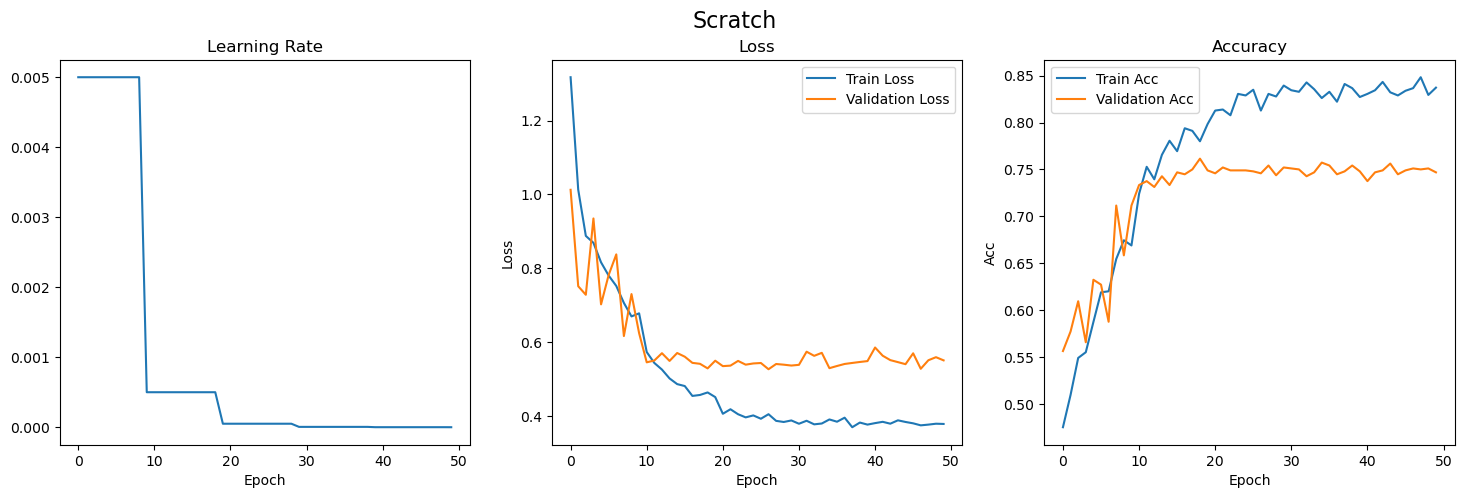

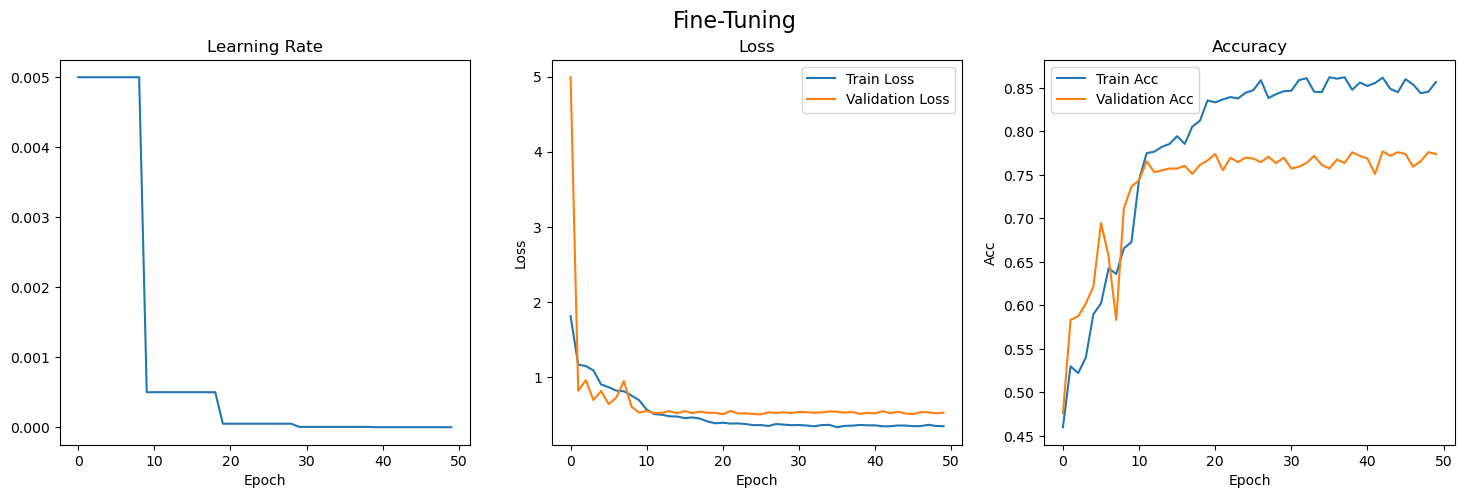

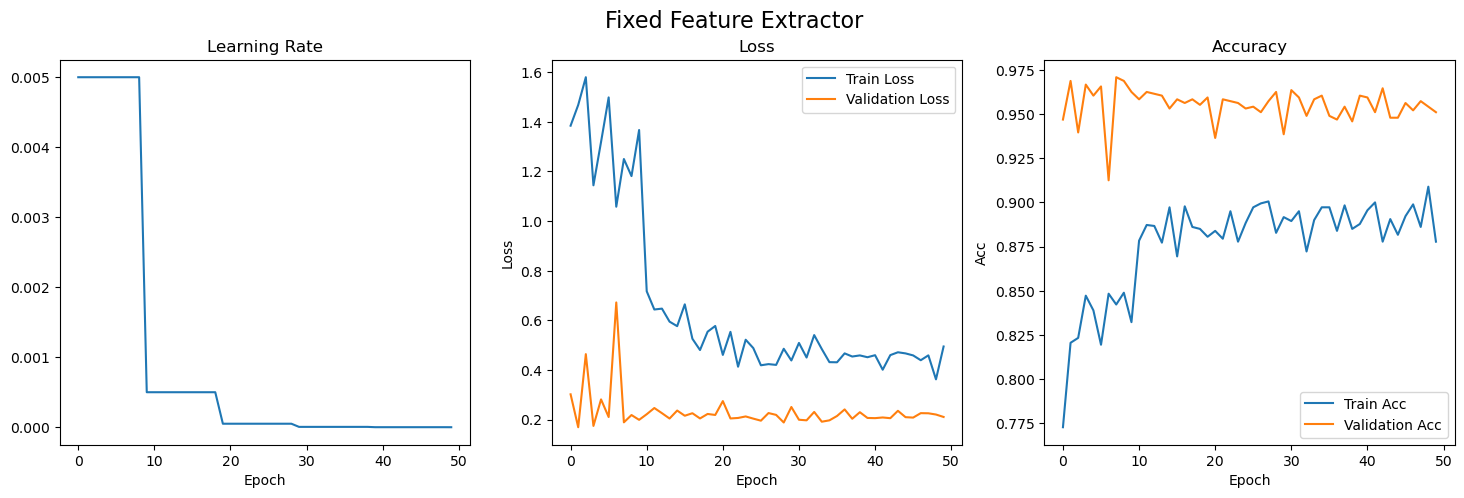

In [10]:
record = [record_scratch, record_fine_tuning, record_fixed]
for i in range(3):
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(['Scratch', 'Fine-Tuning', 'Fixed Feature Extractor'][i], fontsize=16)
    learning_rate_plot = list()
    for j in range(len(record[i][4])):
        if j % 2 == 0:
            learning_rate_plot.append(record[i][4][j])   # 4th element is the learning rate record, j is the index(epoch) of the learning rate record.

    # plot, y_axis, legend       
    ax[0].plot(learning_rate_plot)
    ax[0].set_title('Learning Rate')

    ax[1].plot(record[i][0])
    ax[1].plot(record[i][2])
    ax[1].set_title('Loss')
    ax[1].legend(['Train Loss', 'Validation Loss'])
    ax[1].set_ylabel('Loss')

    ax[2].plot(record[i][1])
    ax[2].plot(record[i][3])
    ax[2].set_title('Accuracy')
    ax[2].legend(['Train Acc', 'Validation Acc'])
    ax[2].set_ylabel('Acc')

    # set the x-axis label for all subplots
    for j in range(3):
        ax[j].set_xlabel('Epoch')

#### 2.5 Please calculate the confusion matrix and print the accuracy of three models with the test dataset. (10%)
##### (Example figure)
![](https://i.imgur.com/8U2vl7W.png)

### 1. Model predict function

In [12]:
def model_predict(model, img_path):
    img = Image.open(img_path)
    img = data_transforms['val'](img)  #
    img = img.unsqueeze(0)  # It adds a new dimension at index 0.   ex. [1, 3, 224, 224]
    img = img.to(device)  #
    model.eval()
    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)    #ex. score, pred = model(img)  # score is the output of the model, pred is the predicted class index.
    return class_names[pred]

### 2. Model predict

In [13]:
test_dir = './animals/test/'
model_class = os.listdir(test_dir)   # : A list of class subdirectories (e.g., ['cat', 'dog', 'panda']), each containing images of that class.

# prepare lists to store true labels and predicted labels
y_true = list() 
y_pred_scratch, y_pred_fine_tuning, y_pred_fixed = list(), list(), list()   

for i in model_class:
    model_class_dir = os.path.join(test_dir, i)
    model_class_path = os.listdir(model_class_dir)    # lists all image files inside that folder. ➜ ['img1.jpg', 'img2.jpg', ...]
    for j in model_class_path:   # loop through each image file in the class directory
        img_path = os.path.join(test_dir, i, j)   # construct the full path of each image
        y_true.append(i) 
        y_pred_scratch.append(model_predict(model_scratch, img_path))
        y_pred_fine_tuning.append(model_predict(model_fine_tuning, img_path))
        y_pred_fixed.append(model_predict(model_fixed, img_path))


### 3. Confusion Maatrix

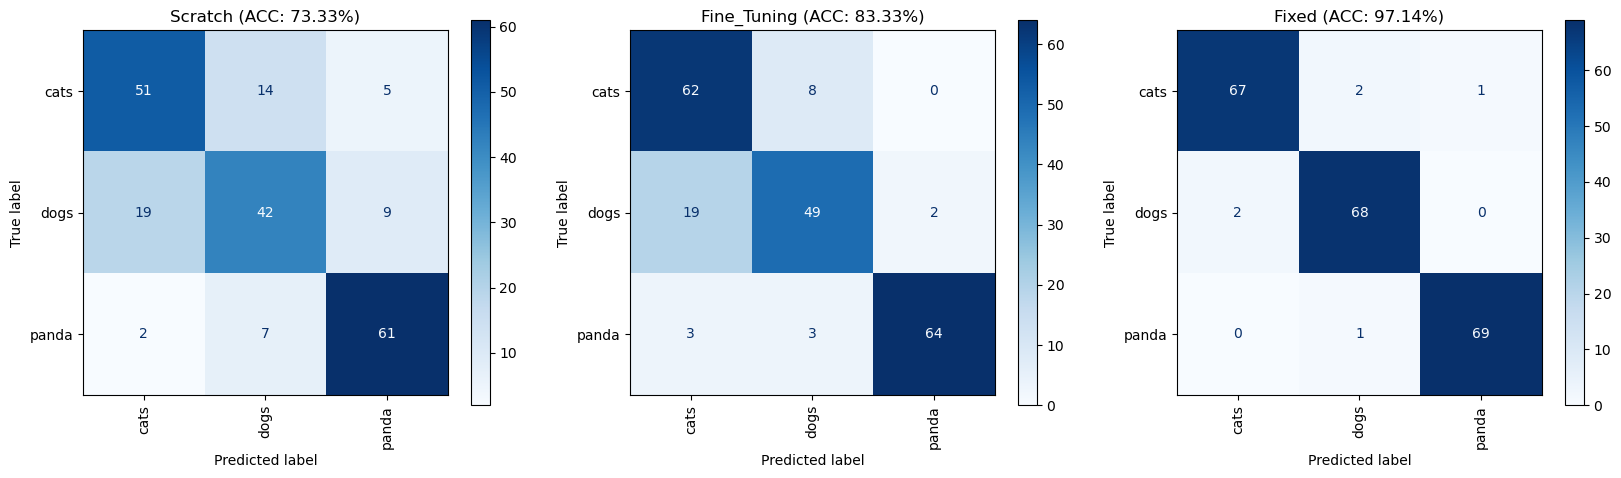

In [14]:
acc_scratch = accuracy_score(y_true, y_pred_scratch)  
cm_scratch = confusion_matrix(y_true, y_pred_scratch, labels=model_class)  # sklearn.metrics: confusion_matrix(y_true, y_pred_scratch, labels=model_class) computes the confusion matrix for the predictions made by the model.
acc_fine_tuning = accuracy_score(y_true, y_pred_fine_tuning)
cm_fine_tuning = confusion_matrix(y_true, y_pred_fine_tuning, labels=model_class)
acc_fixed = accuracy_score(y_true, y_pred_fixed)
cm_fixed = confusion_matrix(y_true, y_pred_fixed, labels=model_class)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_scratch, display_labels=model_class)
disp.plot(ax=ax[0], xticks_rotation='vertical', cmap='Blues')
ax[0].set_title('Scratch (ACC: {:.2f}%)'.format(acc_scratch*100))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_fine_tuning, display_labels=model_class)
disp.plot(ax=ax[1], xticks_rotation='vertical', cmap='Blues')
ax[1].set_title('Fine_Tuning (ACC: {:.2f}%)'.format(acc_fine_tuning*100))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_fixed, display_labels=model_class)
disp.plot(ax=ax[2], xticks_rotation='vertical', cmap='Blues')
ax[2].set_title('Fixed (ACC: {:.2f}%)'.format(acc_fixed*100))
plt.show()

#### 2.6 Please choose the best model to predict the categories of images in the ***./animals/predict*** folder and show the figure with the prediction as title of each axes. (10%)
##### (Example figure)
![](https://i.imgur.com/Z5v7rET.jpg)

C:\Users\USER\AppData\Local\Temp\ipykernel_3928\3126351294.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_fixed.load_state_dict(torch.load("./model_save/model_fix

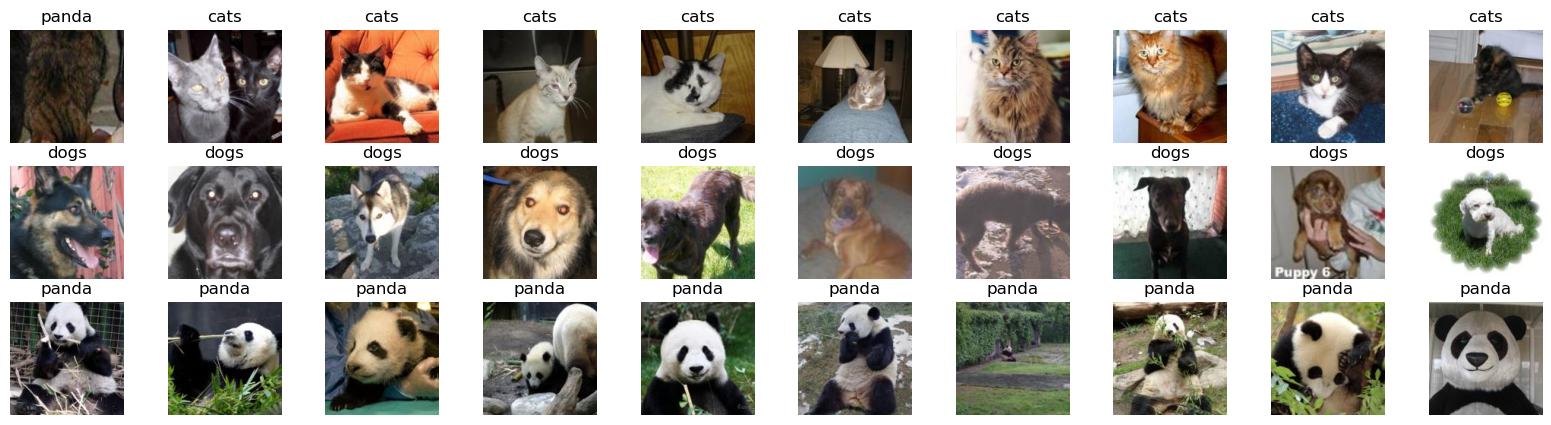

In [16]:
model_fixed.load_state_dict(torch.load("./model_save/model_fixed_best_params.pt"))

# prepare each image path for prediction
test_dir = './animals/prediction/'
prediction_filename = os.listdir(test_dir)
prediction_path = [os.path.join(test_dir, i) for i in prediction_filename]

# 
y_pred = list()
for i in prediction_path:
    y_pred.append(model_predict(model_fixed, i))
    
fig, ax = plt.subplots(3, 10, figsize=(20, 5))
for i in range(len(prediction_path)):
    img = np.array(Image.open(prediction_path[i]))
    ax[i//10, i%10].imshow(img)
    ax[i//10, i%10].axis('off')
    ax[i//10, i%10].set_title(y_pred[i])